#   **5 November 2025**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Note the **Fourier Transform** ($t$-space to $\omega$-space) and its inverse ($\omega$-space to $t$-space)

$$Y(\omega) = \int_{-\infty}^{+\infty}{dt \frac{e^{-i\omega t}}{\sqrt{2\pi}} y(t)}$$
$$y(t) = \int_{-\infty}^{+\infty}{d\omega \frac{e^{+i\omega t}}{\sqrt{2\pi}} Y(\omega)}$$


and its discrete form, where we go through every point in any specified dataset:

\begin{align*}
Y_n &= \frac{1}{\sqrt{2\pi}} \sum_{k=1}^{N}{[ \cos(nk\theta)\Re y_k + \sin(nk\theta)\Im y_k + i(\cos(nk\theta)\Im y_k - \sin(nk\theta)\Re y_k) ]} \\
y_k &= \frac{\sqrt{2\pi}}{N} \sum_{n=1}^{N}{[ \cos(nk\theta)\Re Y_n - \sin(nk\theta)\Im Y_n + i(\cos(nk\theta)\Im Y_n - \sin(nk\theta)\Re Y_n) ]}
\end{align*}

##  Demonstration

In [174]:
N = 1_000
x = np.linspace(0, 18*2*np.pi, N)
deltaT = x[1] - x[0]

f = 1
y_n = np.cos(2*np.pi*f*x)

freqs = np.fft.fftfreq(N, deltaT)
Y_k = np.fft.fft(y_n)
#Y_k = np.fft.fftshift(y_n)

Y_k_mag = np.abs(Y_k)
Y_k_phase = np.angle(Y_k)
Y_k_phase = np.unwrap(Y_k_phase)

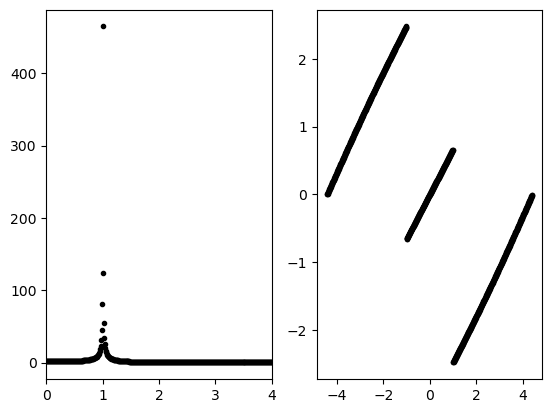

In [175]:
fig, ax = plt.subplots(1, 2)

ax[0].plot(freqs, Y_k_mag, 'k.')
ax[1].plot(freqs, Y_k_phase, 'k.')
ax[0].set_xlim(0,4);

##  Some waveforms of interest

### Sinusoid of single frequency $f$, varying phase shift $\theta$

Recall the general form of a sinusoid
$$y(t) = A\sin(2\pi ft + \theta) + y_0$$
$$y(t) = A\cos(2\pi ft + \theta) + y_0$$

where $A$ is the amplitude, $2\pi f = \omega$ is the angular frequency, $\theta$ is some phase shift in radians, and $y_0$ is some vertical displacement. Also recall that $\sin(t)$ and $\cos(t)$ have a phase difference of $\theta=\frac{\pi}{2}$.

In [176]:
N = np.int32(1E3)
x_max = 20*2*np.pi
x = np.linspace(-x_max, x_max, N)
deltaT = x[1] - x[0]

f = 1
theta = np.linspace(0, 2*np.pi, 10)
y_0 = 0
y_n = np.array([np.sin(2*np.pi*f*x + i) + y_0 for i in theta])            #   Creates a 'list' of y_n with various thetas

freqs = np.fft.fftfreq(N, deltaT)
Y_k = np.fft.fft(y_n)
#Y_k = np.fft.fftshift(Y_k)

Y_k_mag = np.abs(Y_k)
Y_k_phase = np.angle(Y_k)
Y_k_phase = np.unwrap(Y_k_phase)

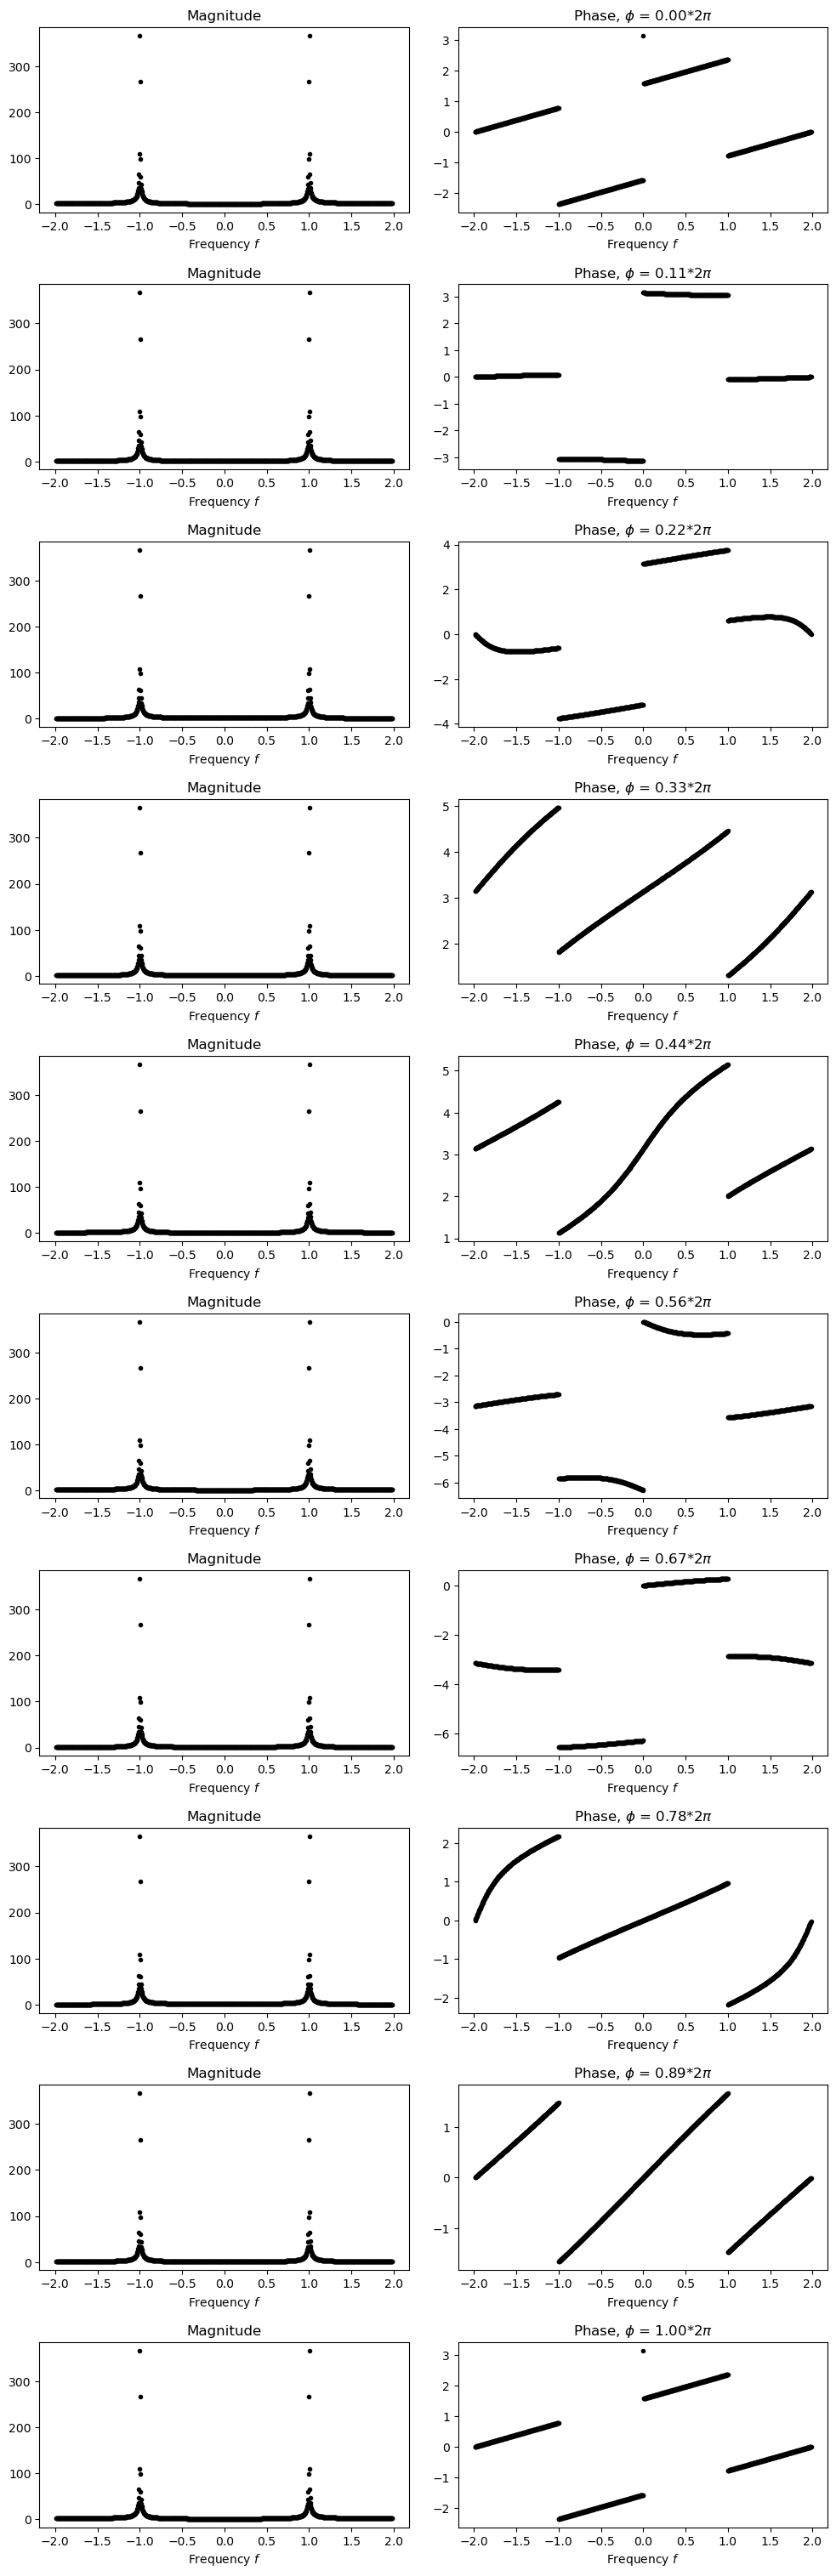

In [177]:
fig, ax = plt.subplots(y_n.shape[0], 2, figsize=(10, 30));
#fig = plt.figure(figsize=(100, 100))
fig.tight_layout(h_pad=4)

#.set_xlim(0,4);
vars = zip(Y_k_mag, Y_k_phase, theta)
sorted_vars = sorted(vars, key = lambda x: x[2])
i = 0 
for mag, phase, theta in sorted_vars:
    ax[i, 0].plot(freqs, mag, 'k.');
    ax[i, 0].set_title(f'Magnitude', loc='center')
    ax[i, 0].set_xlabel(f'Frequency $f$')
    ax[i, 1].plot(freqs, phase, 'k.');
    ax[i, 1].set_title(f'Phase, $\\phi$ = {theta/(2*np.pi):.2f}*2$\\pi$')
    ax[i, 1].set_xlabel(f'Frequency $f$')
    i += 1
plt.show()

### Sum of sinusoids with different frequencies and phases

Let us now consider the superposition of various sinusoids:

$$y(t) = \sum_{i=0}^{N-1}{A_i\sin(2\pi f_it + \theta_i) + y_{0i}}$$

where $A$ is the amplitude, $2\pi f = \omega$ is the angular frequency, $\theta$ is some phase shift in radians, and $y_0$ is some vertical displacement. Each sinusoid term will have one of the aforementioned properties and our sum is already adjusted to the Python way of indexing. Also recall that $\sin(t)$ and $\cos(t)$ have a phase difference of $\theta=\frac{\pi}{2}$.

We can start with the generation of our sinusoids using randomization.

In [182]:
rng = np.random.default_rng()

#   Generation of waves
N_terms = 5         #   set how many terms in sum
f_max = 20         #   set maximum frequency
t_max = 2*np.pi     #   set maximum phase shift
y_max = 10          #   set maximum vertical displacement
A_max = 10          #   set maximum amplitude
f_i     = rng.uniform(0, f_max, size=N_terms)
theta_i = rng.uniform(0, t_max, size=N_terms)
y_0i    = rng.uniform(0, y_max, size=N_terms)*0         #   set 0/1 to turn off/on vertical displacement
A_i     = rng.uniform(0, A_max, size=N_terms)

#   Generation of spatial axis
N_reso = np.int32(1E3)
x_max = 20*2*np.pi
x = np.linspace(-x_max, x_max, N_reso)
deltaT = x[1] - x[0]

#   Superposition of waves
y_n = 0
for A, f, t, y in zip(A_i, f_i, theta_i, y_0i):
    y_n += A*np.sin(2*np.pi*f*x + t) + y

#   Fourier Transform
freqs = np.fft.fftfreq(N_reso, deltaT)
Y_k = np.fft.fft(y_n)
#Y_k = np.fft.fftshift(Y_k)

Y_k_mag = np.abs(Y_k)
Y_k_phase = np.angle(Y_k)
Y_k_phase = np.unwrap(Y_k_phase)

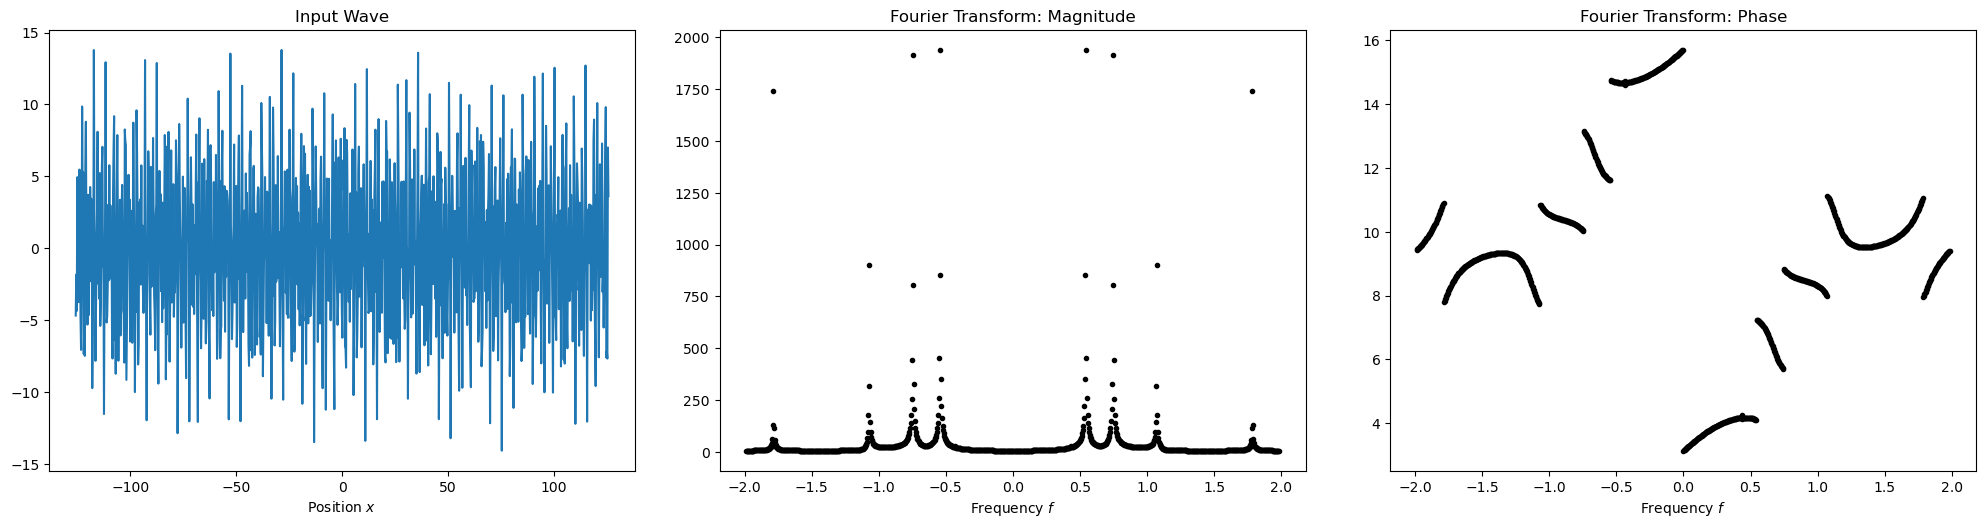

In [183]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
fig.tight_layout(h_pad=1, w_pad=3)

ax[0].plot(x, y_n)
ax[0].set_title(f'Input Wave')
ax[0].set_xlabel(f'Position $x$')
ax[1].plot(freqs, Y_k_mag, 'k.')
ax[1].set_title(f'Fourier Transform: Magnitude')
ax[1].set_xlabel(f'Frequency $f$')
ax[2].plot(freqs, Y_k_phase, 'k.')
ax[2].set_title(f'Fourier Transform: Phase')
ax[2].set_xlabel(f'Frequency $f$')

plt.show()

We expect the Fourier Transform of superpositions to be a collection of Dirac deltas centered at the fundamental frequencies.

### Product of sinusoids with different frequencies and phases

The idea for products of waves remain mostly analogous to the superposition.

$$y(t) = \prod_{i=0}^{N-1}{A_i\sin(2\pi f_it + \theta_i) + y_{0i}}$$

where $A$ is the amplitude, $2\pi f = \omega$ is the angular frequency, $\theta$ is some phase shift in radians, and $y_0$ is some vertical displacement. Each sinusoid term will have one of the aforementioned properties and our sum is already adjusted to the Python way of indexing. Also recall that $\sin(t)$ and $\cos(t)$ have a phase difference of $\theta=\frac{\pi}{2}$.

In [184]:
rng = np.random.default_rng()

#   Generation of waves
N_terms = 5         #   set how many terms in product
f_max = 20         #   set maximum frequency
t_max = 2*np.pi     #   set maximum phase shift
y_max = 10          #   set maximum vertical displacement
A_max = 10          #   set maximum amplitude
f_i     = rng.uniform(0, f_max, size=N_terms)
theta_i = rng.uniform(0, t_max, size=N_terms)
y_0i    = rng.uniform(0, y_max, size=N_terms)*0         #   set 0/1 to turn off/on vertical displacement
A_i     = rng.uniform(0, A_max, size=N_terms)

#   Generation of spatial axis
N_reso = np.int32(1E3)
x_max = 20*2*np.pi
x = np.linspace(-x_max, x_max, N_reso)
deltaT = x[1] - x[0]

#   Multiplication of waves
y_n = 1
for A, f, t, y in zip(A_i, f_i, theta_i, y_0i):
    y_n *= A*np.sin(2*np.pi*f*x + t) + y

#   Fourier Transform
freqs = np.fft.fftfreq(N_reso, deltaT)
Y_k = np.fft.fft(y_n)
#Y_k = np.fft.fftshift(Y_k)

Y_k_mag = np.abs(Y_k)
Y_k_phase = np.angle(Y_k)
Y_k_phase = np.unwrap(Y_k_phase)

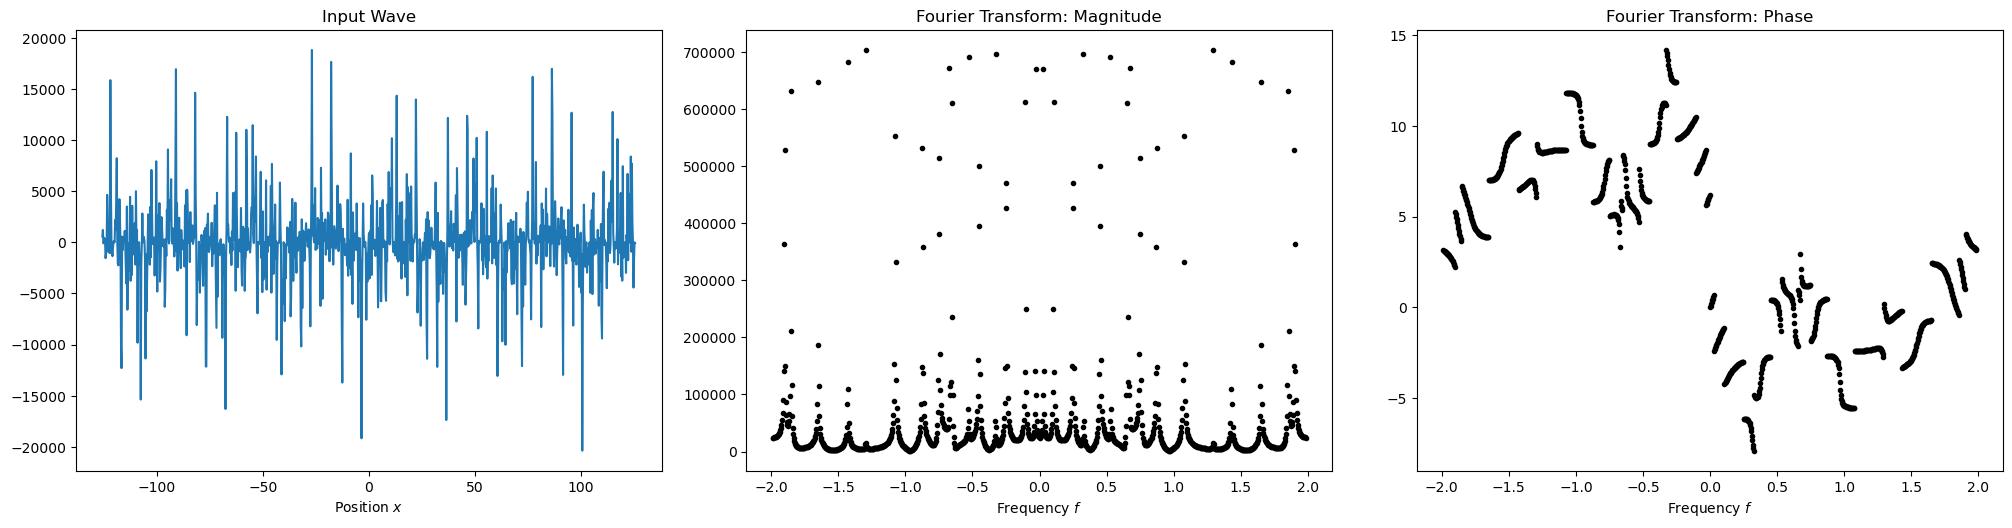

In [185]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
fig.tight_layout(h_pad=1, w_pad=3)

ax[0].plot(x, y_n)
ax[0].set_title(f'Input Wave')
ax[0].set_xlabel(f'Position $x$')
ax[1].plot(freqs, Y_k_mag, 'k.')
ax[1].set_title(f'Fourier Transform: Magnitude')
ax[1].set_xlabel(f'Frequency $f$')
ax[2].plot(freqs, Y_k_phase, 'k.')
ax[2].set_title(f'Fourier Transform: Phase')
ax[2].set_xlabel(f'Frequency $f$')

plt.show()

### Finite-time sinusoid

### Square wave (single and periodic)

Recall that a square wave could simply take the sign of the general sinusoid function.

\begin{align*}
y(t) &= \text{sgn}(A\sin(2\pi ft + \theta) + y_0) \qquad &\\
y(t) &= A \ \text{sgn}(\sin(2\pi ft + \theta))      & \text{if} \ y_0 = 0 
\end{align*}

In physical systems, we note that the bottom wave is 0 and the active amplitude is 1. This needs our function to be normalized and "brought up" to the plane (line, actually) intersecting the origin.

\begin{align*}
y(t) &= A \ \text{sgn}(\sin(2\pi ft + \theta))   \qquad    & \text{if} \ y_0 = 0 \\
y_{\text{norm}}(t) &= \text{sgn}(\sin(2\pi ft + \theta))  & A \cdot \frac{1}{A} = 1 \\
y_{\text{adj}}(t) &= \text{sgn}(\sin(2\pi ft + \theta)) + 1
\end{align*}

For a singular square wave, we can simply define it to be active in the interval that we intend it to.

**Periodic Square Wave**

In [186]:
rng = np.random.default_rng()

#   Generation of waves
N_terms = 1
f_max = 1         #   set maximum frequency
t_max = 2*np.pi     #   set maximum phase shift
y_max = 10          #   set maximum vertical displacement
A_max = 10          #   set maximum amplitude
f_i     = rng.uniform(0, f_max, size=N_terms)
theta_i = rng.uniform(0, t_max, size=N_terms)
y_0i    = rng.uniform(0, y_max, size=N_terms)*0         #   set 0/1 to turn off/on vertical displacement
A_i     = rng.uniform(0, A_max, size=N_terms)

#   Generation of spatial axis
N_reso = np.int32(1E3)
x_max = 10*2*np.pi
x = np.linspace(-x_max, x_max, N_reso)
deltaT = x[1] - x[0]

for A, f, t, y in zip(A_i, f_i, theta_i, y_0i):
    y_n = np.sign(A*np.sin(2*np.pi*f*x + t) + y)
    y_n_adj = y_n + 1

#   Fourier Transform
freqs = np.fft.fftfreq(N_reso, deltaT)
Y_k = np.fft.fft(y_n)
Y_k_adj = np.fft.fft(y_n_adj)
#Y_k = np.fft.fftshift(Y_k)

Y_k_mag = np.abs(Y_k)
Y_k_phase = np.angle(Y_k)
Y_k_phase = np.unwrap(Y_k_phase)
Y_k_mag_adj = np.abs(Y_k_adj)
Y_k_phase_adj = np.angle(Y_k_adj)
Y_k_phase_adj = np.unwrap(Y_k_phase_adj)

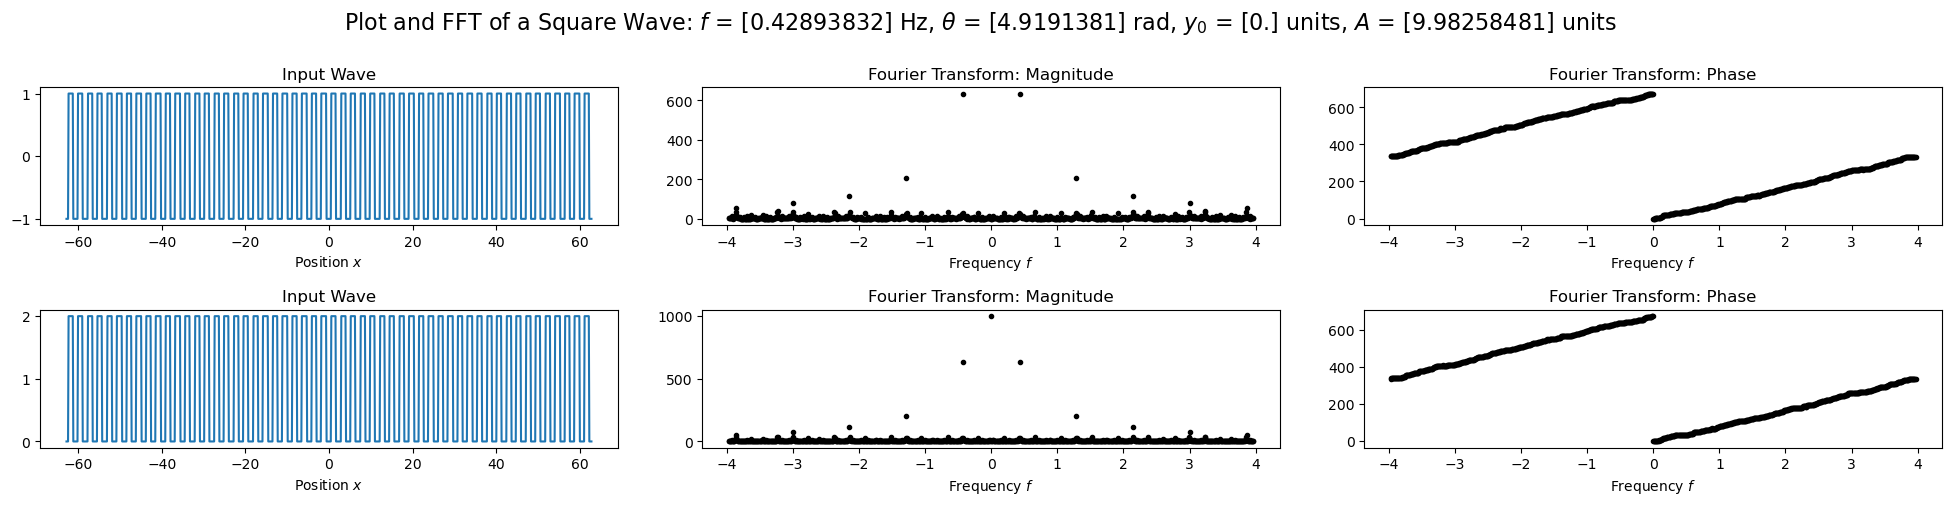

In [187]:
fig, ax = plt.subplots(2, 3, figsize=(20, 5))
fig.suptitle(f'Plot and FFT of a Square Wave: $f$ = {f_i} Hz, $\\theta$ = {theta_i} rad, $y_0$ = {y_0i} units, $A$ = {A_i} units', fontsize=16)
fig.tight_layout(h_pad=4, w_pad=3, pad=2)

#   For the signum function
ax[0, 0].plot(x, y_n)
ax[0, 0].set_title(f'Input Wave')
ax[0, 0].set_xlabel(f'Position $x$')
ax[0, 1].plot(freqs, Y_k_mag, 'k.')
ax[0, 1].set_title(f'Fourier Transform: Magnitude')
ax[0, 1].set_xlabel(f'Frequency $f$')
ax[0, 2].plot(freqs, Y_k_phase, 'k.')
ax[0, 2].set_title(f'Fourier Transform: Phase')
ax[0, 2].set_xlabel(f'Frequency $f$')

#   For the adjusted function
ax[1, 0].plot(x, y_n_adj)
ax[1, 0].set_title(f'Input Wave')
ax[1, 0].set_xlabel(f'Position $x$')
ax[1, 1].plot(freqs, Y_k_mag_adj, 'k.')
ax[1, 1].set_title(f'Fourier Transform: Magnitude')
ax[1, 1].set_xlabel(f'Frequency $f$')
ax[1, 2].plot(freqs, Y_k_phase_adj, 'k.')
ax[1, 2].set_title(f'Fourier Transform: Phase')
ax[1, 2].set_xlabel(f'Frequency $f$')

plt.show()

### Triangle wave

Recall that a triangle wave can be defined by the following piecewise equation:

### Gaussian function

Note the general form of the Gaussian function:

$$f(x) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{\left(x-\mu\right)^2}{2\sigma^2}}$$

where $\mu$ is the mean (the center of the Gaussian), and $\sigma$ is the standard deviation (often also called the half of the full width at half maximum, $\frac{1}{2}\text{FWHM}$).

In [188]:
rng = np.random.default_rng()

#   Generation of waves
N_terms     = 10                                            #   set how many elements in arrays
sigma_max   = 10
mu_max      = 20
sigma_i = rng.uniform(1E-8, sigma_max, size=N_terms)        #   cannot be 0, but we can set the lower limit to be really close.
mu_i    = rng.uniform(0, mu_max, size=N_terms)*0            #   set 0/1 to turn off/on horizontal displacement

#   Generation of spatial axis
N_reso  = np.int32(1E3)
x_max   = 10*2*np.pi
x       = np.linspace(-x_max, x_max, N_reso)
deltaT  = x[1] - x[0]

#   Defining the Gaussian function for various random sigma and mu
y_n = np.array([((1/(np.sqrt(2*np.pi*(sig**2))))*np.exp(-(x-mu)**2/(2*(sig**2)))) for sig, mu in zip(sigma_i, mu_i)])

#   Fourier Transform
freqs   = np.fft.fftfreq(N_reso, deltaT)
Y_k     = np.fft.fft(y_n)
#Y_k = np.fft.fftshift(Y_k)

Y_k_mag     = np.abs(Y_k)
Y_k_phase   = np.angle(Y_k)
Y_k_phase   = np.unwrap(Y_k_phase)

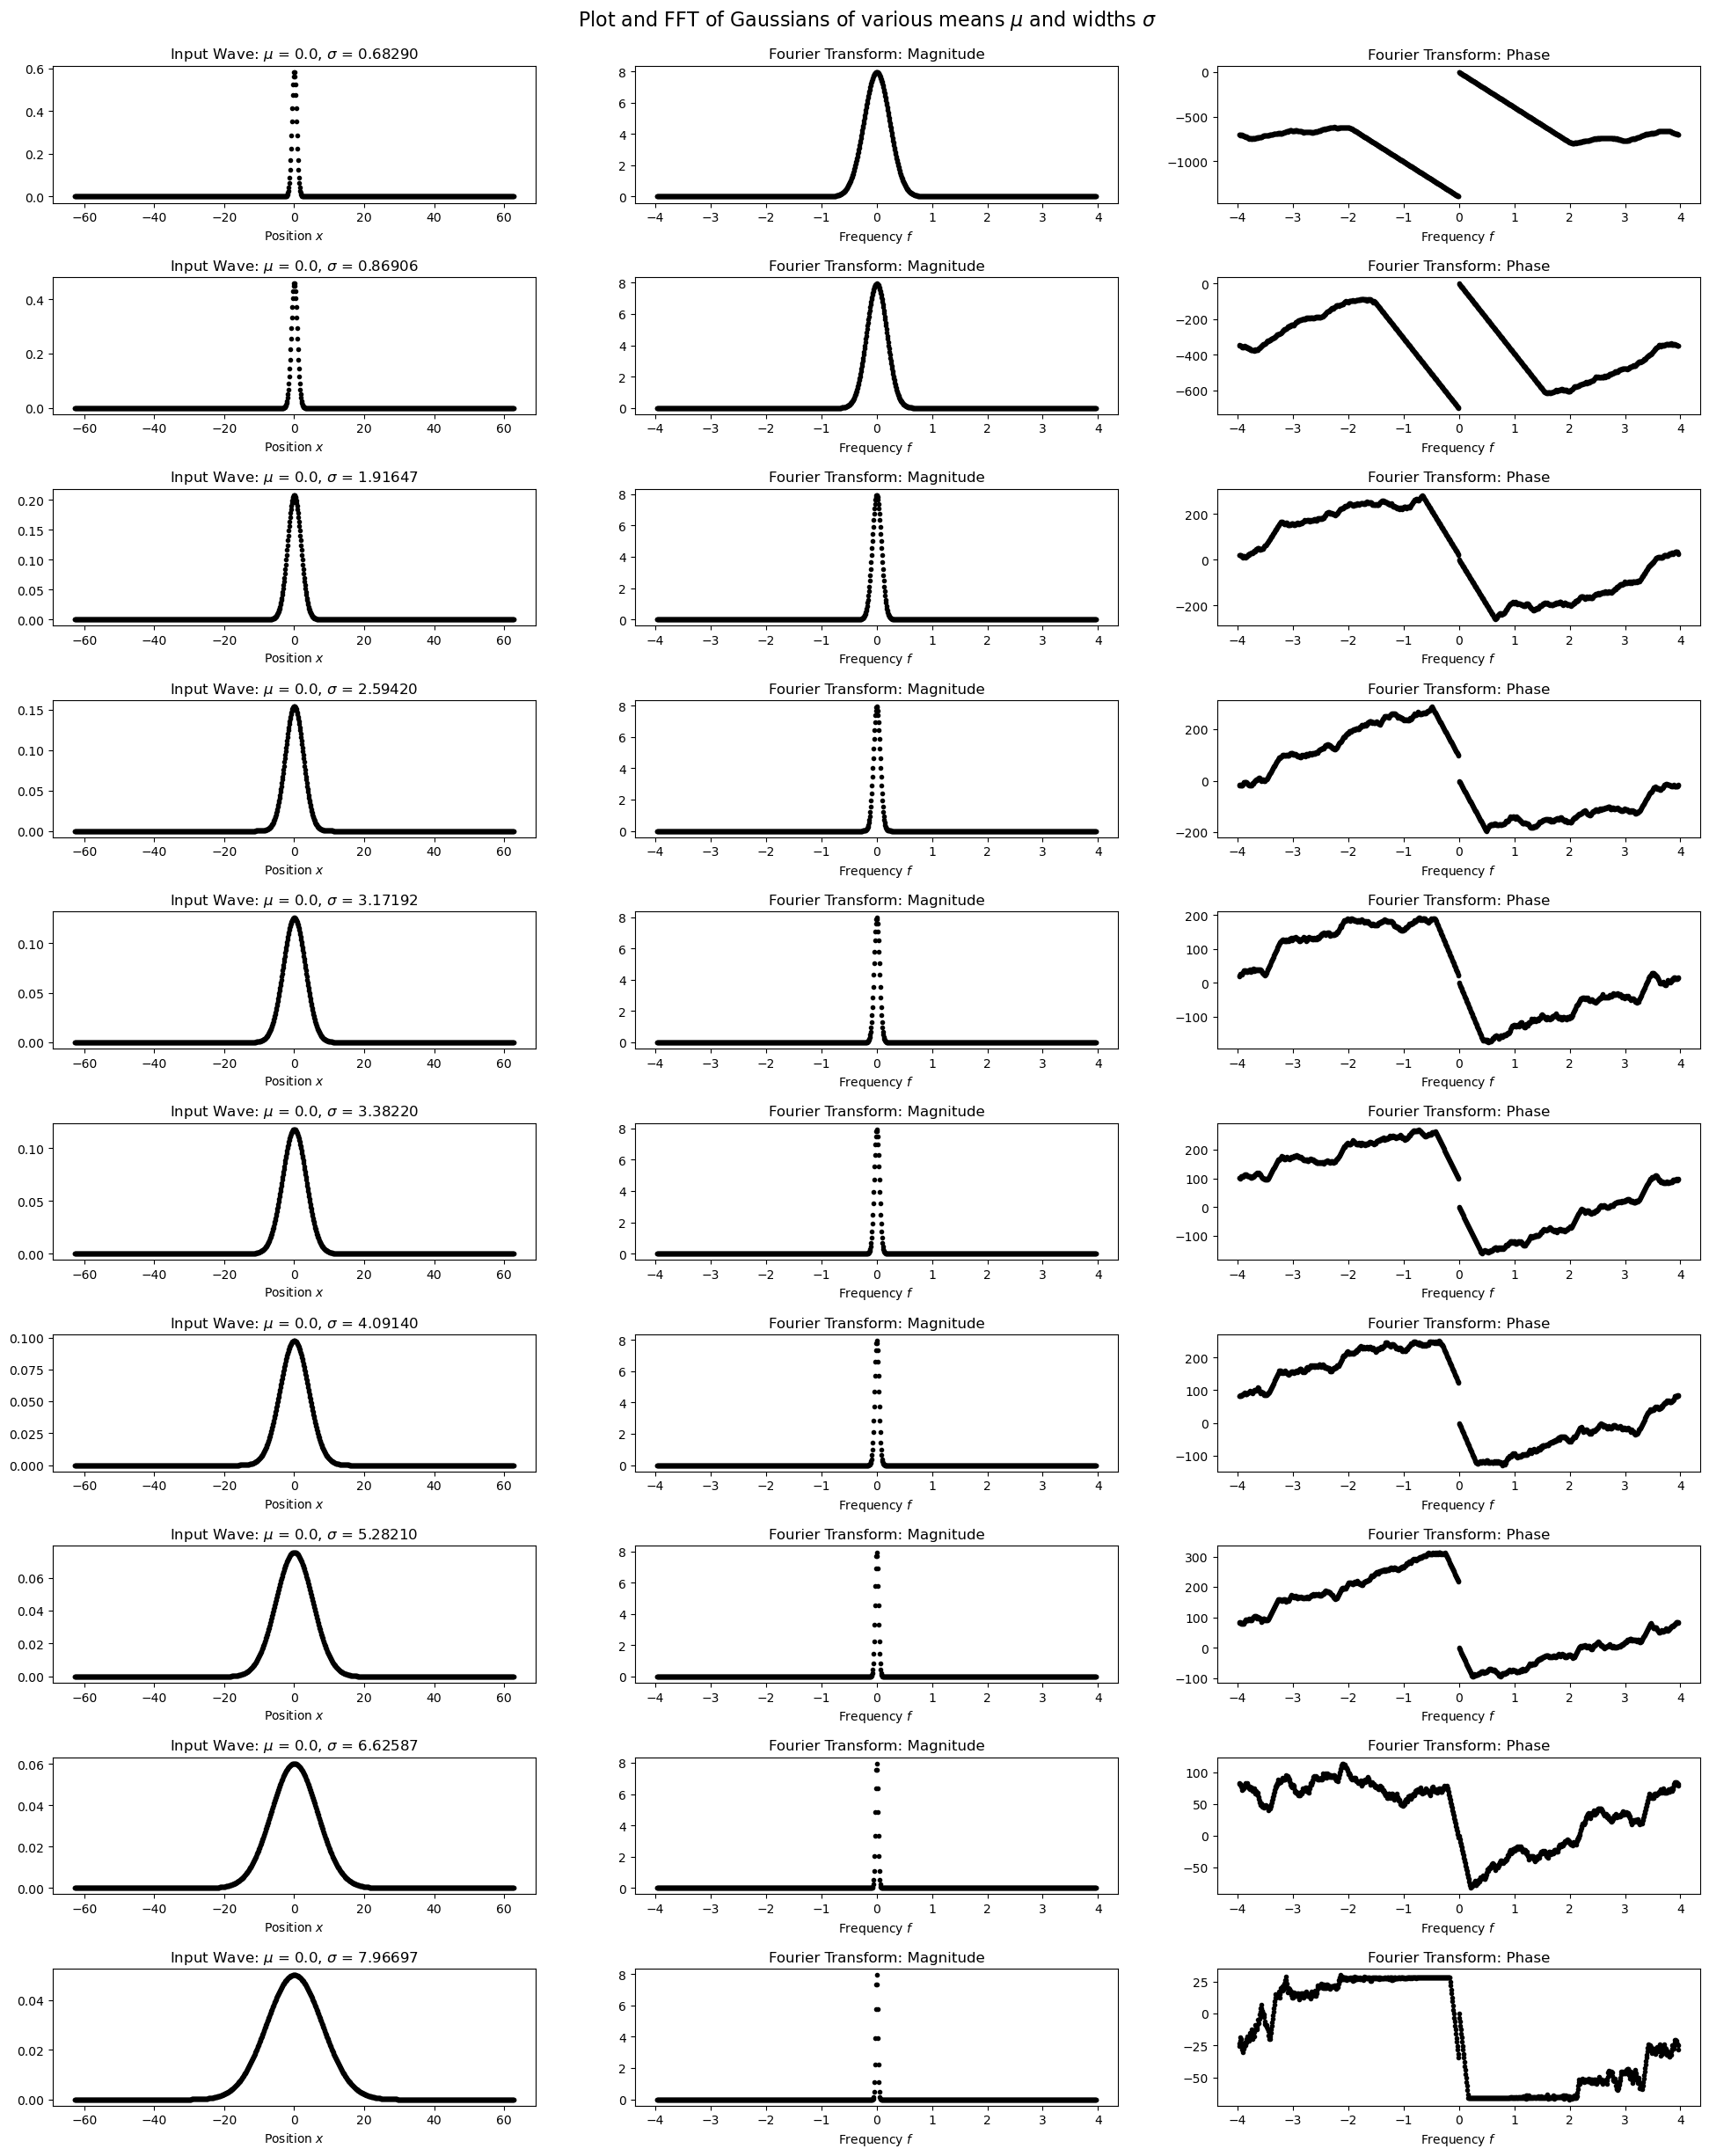

In [190]:
fig, ax = plt.subplots(y_n.shape[0], 3, figsize=(20, 25));
fig.suptitle(f'Plot and FFT of Gaussians of various means $\\mu$ and widths $\\sigma$', fontsize=16)
fig.tight_layout(h_pad=4, w_pad=5, pad=3)

#   We sort it in increasing sigma for easy comparison.
i = 0 
vars = zip(y_n, Y_k_mag, Y_k_phase, mu_i, sigma_i)
sorted_vars = sorted(vars, key=lambda x: x[4])
for orig, mag, phase, mu, sig in sorted_vars:
    ax[i, 0].plot(x, orig, 'k.')
    ax[i, 0].set_title(f'Input Wave: $\\mu$ = {mu}, $\\sigma$ = {sig:.5f}')
    ax[i, 0].set_xlabel(f'Position $x$')
    ax[i, 1].plot(freqs, mag, 'k.');
    ax[i, 1].set_title(f'Fourier Transform: Magnitude')
    ax[i, 1].set_xlabel(f'Frequency $f$')
    ax[i, 2].plot(freqs, phase, 'k.');
    ax[i, 2].set_title(f'Fourier Transform: Phase')
    ax[i, 2].set_xlabel(f'Frequency $f$')
    i += 1
plt.show()

### Gaussian wave packet